# pySTRATA

[**pySTRATA**](https://github.com/arkottke/pystrata) is a Python library for seismic site response analysis (SRA) developed by [Albert Kotkke](https://github.com/arkottke/pystrata/tree/main) based on [**STRATA**](https://github.com/arkottke/strata). **STRATA** is a GUI-based computer program originally developed by [Albert Kottke and Ellen Rathje](https://github.com/arkottke/strata/tree/main). **pySTRATA** offers greater flexibility, facilitating the development of complex customized workflows.

**pySTRATA** models wave propagation through layered soil profiles using one-dimensional:

- ``Linear-elastic (LE)`` SRA
- ``Equivalent-linear (EQL)`` SRA
- ``EQL with frequency-dependent moduli and damping (FDM)`` SRA 

It supports **time-series** and **Random Vibration Theory (RVT)** approaches, as well as logic trees for uncertainty quantification. Additionally, **pySTRATA** provides tools for:

- Estimating site amplification using the ``Quarter-Wavelength (QWL)`` method
- ``Randomization of shear-wave velocity profiles`` using Toro's (1995) model

# 0. Overview

**pySTRATA** requires Python 3.10 or higher and it can be installed using pip, conda, or built from source:

<div style="border: 1px solid #e0e0e0; border-radius: 2px; padding: 5px; font-family: sans-serif; background-color: #fafafa;">
  <div style="background-color: #f5f5f5; border: 1px solid #e0e0e0; border-radius: 4px; padding: 12px; font-family: monospace; position: relative; line-height: 1.6;">
    <code style="color: #212121;">pip install pystrata</code><br>
  </div>
</div>

In [2]:
#!pip install pystrata
import pystrata
print(pystrata.__version__)

# General settings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams['font.family'] = 'Times New Roman'

# Run a simple example
motion = pystrata.motion.SourceTheoryRvtMotion(6.5, 20, "wna")
print("Installation successful!")

0.8.1
Installation successful!


# 1. Objectives

* Conduct 1-D Linear and Equivalent-Linear Site Response Analyses using **pyStrata**
* Compute amplification factors for a range of frequenciees of interest using **pyStrata**
* Utilize the **Pacific Earthquake Engineering Research (PEER) Strong Ground Motion Databases** and the **Center for Engineering Strong Motion Data (CESMD)** to retrieve strong ground motion records
* Manipulate and visualize AT2 and SMC file formats using **pyStrata** scripts

# 2. Linear and equivalent-linear Site Response Analysis (SRA)

**pySTRATA** divides the SRA into five componentes:

- ``Input Motion``: Specification of input Ground Motion at the input location
- ``Site Profile``: Definition of soil profile and material properties
- ``Calculator``: Selection of the analysis method (linear-elastic, equivalent-linear, FDM)
- ``Output``: Specification of desired output quantities and locations
- ``Uncertainty Handling`` (optional): Tools for probabilistic analysis and uncertainty quantification.

Accordingly, the typical workflow involves:

```mermaid
flowchart LR
    A[Define <br>input motion] --> B[Creation <br>site profile]
    B --> C[Selection <br>analysis method]
    C --> D[Output <br>definition]
    D --> E[Run <br>analysis]
    E --> F[Extract/Visualize <br>results]
```

We will introduce **pySTRATA** through an example that demostrates how to use linear-elastic and equivalent-linear SRA.

# 3. Example 

This example demonstrates the basic features of **pySTRATA**. We will analyze how a ground motion is modified as it propagates through a layered soil profile from bedrock to the surface using linear and equivalent-linear approaches. The site stratigraphy and material properties are listed in the table below, with a groundwater table (GWT) at a depth of 6 meters. 




| **Layer** | **Depth (m)**  | **Soil Type**  | $V_{S}$ (m/s) | $\gamma$ (kN/m3) | OCR | PI |  $\zeta$ |
| :-------: | :------:       | :------:       |  :------:      |  :------:      |  :---: | :---: |:---: |
| 1         |  0.0 - 6.0     | Clay           | 250  | 18 | 1 | 15 | - |
| 2         |  6.0 - 30.5    | Clay           | 300  | 18 | 1 | 30 | - |
| 3         | 30.5 - 61.0    | Sand           | 460  | 19 | - | -  | - |
| 4         | 61.0 - 91.0    | Weathered rock | 700  | 22 | - | -  | - |
| 5         | 91.0 - $\infty$| Bedrock        | 1850 | 22 | - | -  | 0.02 |

## 3.1. Load input motion


```mermaid
flowchart LR
    A[Define <br>input motion] --> B[Creation <br>site profile]
    B --> C[Selection <br>analysis method]
    C --> D[Output <br>definition]
    D --> E[Run <br>analysis]
    E --> F[Extract/Visualize <br>results]

    %% Color Style for Node A
    style A fill:#bbf,stroke:#333,stroke-width:2px,color:#000
```

In this example, we are going to use an Input Motion recorded at the [``Nishi-Akashi station``](https://www.strongmotioncenter.org/vdc/scripts/stnpage.plx?stations=4044) during the [``1995 Mw6.9 Kobe Earthquake``](https://earthquake.usgs.gov/earthquakes/eventpage/usp0006rew/executive).

Main characteristics:

* Date and time (UTC): January 16, 1995 20:46:52
* Tectonic Regime (Garcia *et al.*, 2012): Crustal
* Mw: 6.9
* Depth: 21.9 km

<a href="https://earthquake.usgs.gov/earthquakes/eventpage/usp0006rew/shakemap/intensity">
    <img src="https://earthquake.usgs.gov/product/shakemap/usp0006rew/atlas/1594167475099/download/intensity.jpg" width="500" height="700" alt="Description">
</a>

The time series is located in the [data folder](./data/NIS090.AT2) in ``AT2`` format. The AT2 file format is a standardized structure used in the Pacific Earthquake Engineering Research (PEER) [Strong Ground Motion Databases](https://peer.berkeley.edu/peer-strong-ground-motion-databases). **pySTRATA** can read the ``AT2`` format natively using the function ``pystrata.motion.TimeSeriesMotion.load_at2_file()``:

In [3]:
# Load an input motion
filename = "data/NIS090.AT2"
NIS090 = pystrata.motion.TimeSeriesMotion.load_at2_file(filename)
print(NIS090)


**pySTRATA** can also read ground motions in ``SMC`` format. The SMC files are standard ASCII text data files used to store earthquake strong-motion accelerograms, response spectra, or Fourier amplitude spectra by the [Center for Engineering Strong Motion Data (CESMD)](https://www.strongmotioncenter.org) and the [Consortium of Organizations for Strong-Motion Observation Systems (COSMOS)](https://www.strongmotion.org/data-centers). To read ``SMC`` files in **pySTRATA**, we can use the function ``pystrata.motion.TimeSeriesMotion.load_smc_file()``.

Additionally, you can directly specify the time series using the function `pystrata.motion.TimeSeriesMotion()`. For example:

```python
motion = pystrata.motion.TimeSeriesMotion(
    filename="custom_motion",
    description="Custom time series",
    time_step=0.01,  # seconds
    accels=[0.1, 0.2, 0.15, ...]  # acceleration values in g
)
```

**pySTRATA** calculates automatically several useful properties and intensity measures of the time series, which are saved in the ``motion`` class and can be accessed using the following:

- **Time steps (s)**: `motion.time_step`
- **Time vector**: `motion.times` 
- **Acceleration values (g)**: `motion.accels`
- **Frequency vector (Hz)**: `motion.freqs`
- **Fourier amplitude**: `motion.fourier_amps`
- **PGA (g)**: `motion.pga`
- **PGV (cm/s)**: `motion.pgv`


PGA (g): 0.503
PGV (cm/s): 0.366


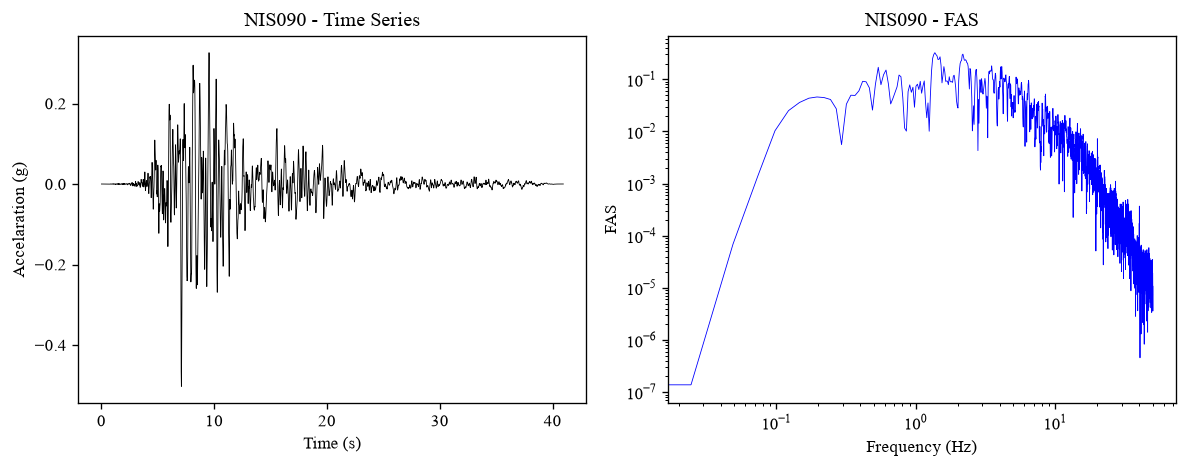

In [4]:
print(f"PGA (g): {np.round(NIS090.pga,3)}")
print(f"PGV (cm/s): {np.round(NIS090.pgv,3)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Time series
ax1.plot(NIS090.times, NIS090.accels, color='black', lw=0.5)
ax1.set_title('NIS090 - Time Series')
ax1.set(xlabel="Time (s)", ylabel="Accelaration (g)")

# FAS
FAS_values = np.abs(NIS090.fourier_amps) # Extract magnitude
ax2.plot(NIS090.freqs, FAS_values, color='blue', lw=0.5)
ax2.set_title('NIS090 - FAS')
ax2.set(xlabel="Frequency (Hz)", xscale="log", ylabel="FAS", yscale="log")

plt.tight_layout()
plt.show()

We can also compute the Pseudo-Aceleration (PSA) Response Spectrum using `motion.calc_osc_accels('freqs','damping')`:

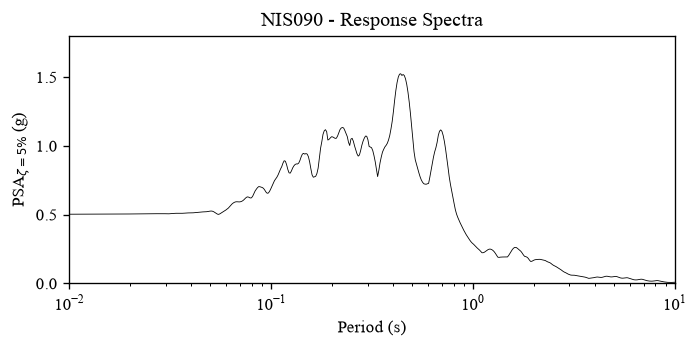

In [28]:
periods_PSA = np.logspace(-2, 1, 500)
freqs_PSA = 1/periods_PSA
damping_PSA = 0.05

PSA_NIS090 = NIS090.calc_osc_accels(freqs_PSA, damping_PSA)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(periods_PSA, PSA_NIS090, color="black", lw=0.5)
ax.set(xlabel="Period (s)", xscale = 'log', ylabel=r"PSA$_{\zeta=5\%}$ (g)")
ax.set_title('NIS090 - Response Spectra')
plt.ylim([0,1.8]); plt.xlim([0.01,10])
fig.tight_layout()
plt.show()

## 3.2. Create Site Profile

```mermaid
flowchart LR
    A[Define <br>input motion] --> B[Creation <br>site profile]
    B --> C[Selection <br>analysis method]
    C --> D[Output <br>definition]
    D --> E[Run <br>analysis]
    E --> F[Extract/Visualize <br>results]

    %% Color Style for Node A
    style B fill:#bbf,stroke:#333,stroke-width:2px,color:#000
```

To represent a site profile with an infinite halfspace at the base, **pySTRATA** uses the ``Profile`` class. This is a collection of layers (class `Layers`) which are defined by:

- `Soil Type`: Includes all the information about soil properties
- `Shear Wave Velocity`: Low-strain (initial) shear wave velocity in $\text{m/s}$
- `Thickness`: Layer thickness in $\text{m}$

### 3.2.1. Soil Types

#### 3.2.1.1. Generalities

For a general soil, **pySTRATA** uses the class `pystrata.site.SoilType()`. It requires the definitions of:

- `name`: String used for identification (optional)
- `unit_wt`: Unit weight in $\text{kN/m}^3$
- `mod_reduc`: Shear-Modulus reduction curve (optional). For linear behavior, select `None`
- `damping`: Damping ratio (**decimal**)

**pySTRATA** has implemented several empirical models to capture nonlinear stress-strain behavior under dynamic loading (*e.g.*, stiffness reduction and damping increment as shear strain increases). The catalog of published nonlinear curves can be accessed using the function `pystrata.site.known_published_curves()`: 


In [5]:
list_nonlinear_models = pystrata.site.known_published_curves()
print("\n".join(list_nonlinear_models))

Vucetic & Dobry (91), PI=0
Vucetic & Dobry (91), PI=15
Vucetic & Dobry (91), PI=30
Vucetic & Dobry (91), PI=50
Vucetic & Dobry (91), PI=100
Vucetic & Dobry (91), PI=200
EPRI (93), PI=10
EPRI (93), PI=30
EPRI (93), PI=50
EPRI (93), PI=70
EPRI (93), 0-20 ft
EPRI (93), 20-50 ft
EPRI (93), 50-120 ft
EPRI (93), 120-250 ft
EPRI (93), 250-500 ft
EPRI (93), 500-1000 ft
GEI (83), 0-50 ft
GEI (83), 50-100 ft
GEI (83), 100-250 ft
GEI (83), 250-500 ft
GEI (83), >500 ft
GeoMatrix (1990), 0-50 ft
GeoMatrix (1990), 50-150 ft
GeoMatrix (1990), >150 ft
GeoMatrix (1990), 150-300 ft
GeoMatrix (1990), >300 ft
Idriss (1990), Clay
Idriss (1990), Sand
Imperial Valley Soils, 0-300 ft
Imperial Valley Soils, >300 ft
Iwasaki, 0.25 atm
Iwasaki, 1.0 atm
Peninsular Range, Cohesionless 0-50 ft
Peninsular Range, Cohesionless 50-500 ft
Seed & Idriss, Sand Mean
Seed & Idriss, Sand Upper
Seed & Idriss, Sand Lower


To access the curves, we use the function `pystrata.site._load_published_curves()`:

In [6]:
pystrata.site._load_published_curves()
models = pystrata.site.PUBLISHED_CURVES

# Saving them as DataFrame
nonlinear_models = pd.DataFrame(models).T.reset_index(drop=True)
# To have access to a curve family
nonlinear_models[["source", "suffix"]]= nonlinear_models.name.str.split(",", expand=True) 
nonlinear_models.head()

,name,mod_reduc,damping,source,suffix
0,"Vucetic & Dobry (91), PI=0","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...",Vucetic & Dobry (91),PI=0
1,"Vucetic & Dobry (91), PI=15","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...",Vucetic & Dobry (91),PI=15
2,"Vucetic & Dobry (91), PI=30","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...",Vucetic & Dobry (91),PI=30
3,"Vucetic & Dobry (91), PI=50","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...",Vucetic & Dobry (91),PI=50
4,"Vucetic & Dobry (91), PI=100","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...","{'strains': [1e-06, 3.16e-06, 1e-05, 3.16e-05,...",Vucetic & Dobry (91),PI=100


Comparing [Vucetic & Dobry (1991)](https://ascelibrary.org/doi/10.1061/%28ASCE%290733-9410%281991%29117%3A1%2889%29) curves against [EPRI (1993)](https://www.epri.com/research/products/tr-102293-v1):

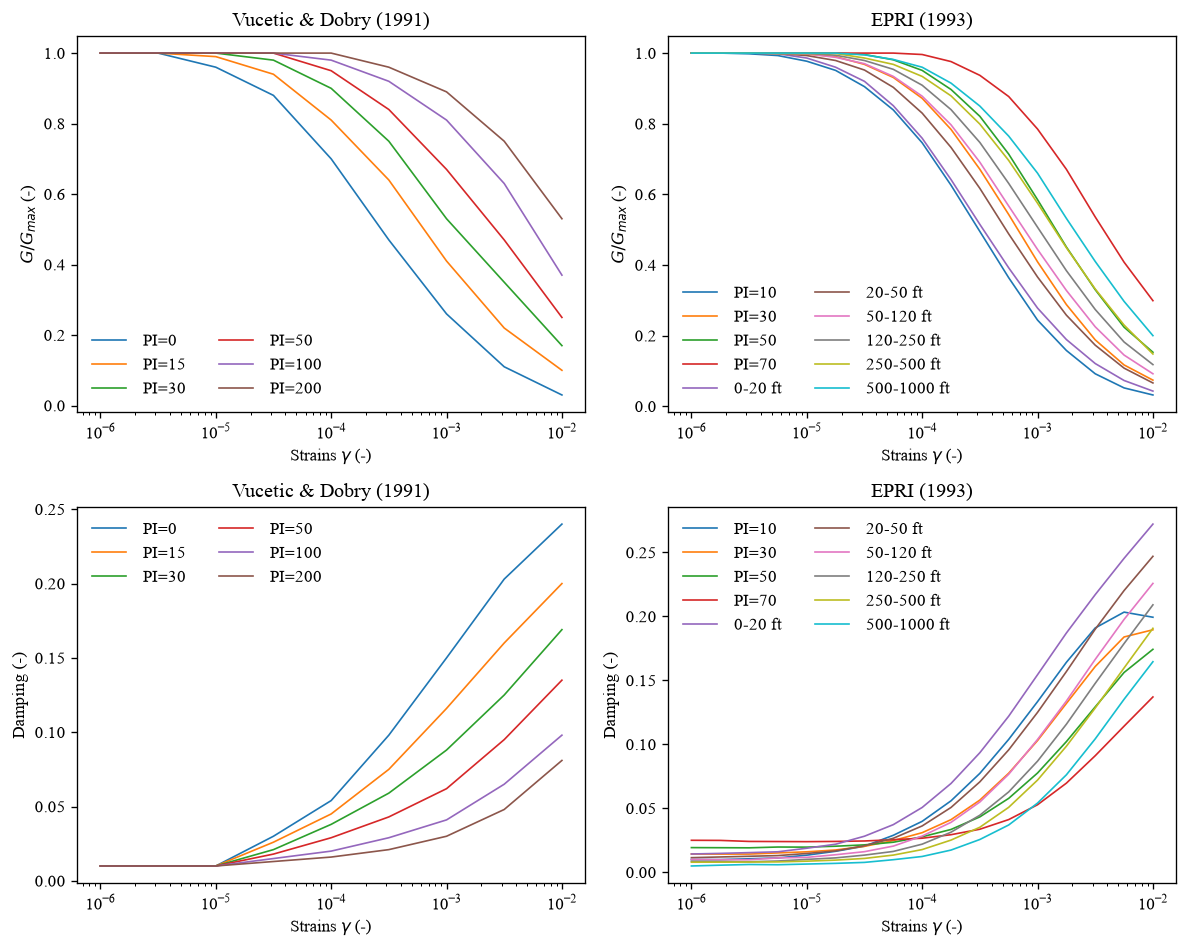

In [7]:
# Reading data
VD91 = nonlinear_models[nonlinear_models['source']=='Vucetic & Dobry (91)']
EPRI93 = nonlinear_models[nonlinear_models['source']=='EPRI (93)']

# Plots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Vucetic & Dobry (1991)
# Modulus Reduction Curve
for i, row in VD91.reset_index(drop=True).iterrows():
    axs[0,0].plot(row.mod_reduc['strains'], row.mod_reduc['values'], lw=1, label=row.suffix)
axs[0,0].set_title('Vucetic & Dobry (1991)')
axs[0,0].legend(loc="lower left",  ncols=2, frameon=False)
axs[0,0].set(xlabel=r"Strains $\gamma$ (-)", xscale="log", ylabel=r"$G/G_{max}$ (-)")

# Damping 
for i, row in VD91.reset_index(drop=True).iterrows():
    axs[1,0].plot(row.damping['strains'], row.damping['values'], lw=1, label=row.suffix)
axs[1,0].set_title('Vucetic & Dobry (1991)')
axs[1,0].legend(loc="upper left",  ncols=2, frameon=False)
axs[1,0].set(xlabel=r"Strains $\gamma$ (-)", xscale="log", ylabel="Damping (-)")

# EPRI (1993)
# Modulus Reduction Curve
for i, row in EPRI93.reset_index(drop=True).iterrows():
    axs[0,1].plot(row.mod_reduc['strains'], row.mod_reduc['values'], lw=1, label=row.suffix)
axs[0,1].set_title('EPRI (1993)')
axs[0,1].legend(loc="lower left",  ncols=2, frameon=False)
axs[0,1].set(xlabel=r"Strains $\gamma$ (-)", xscale="log", ylabel=r"$G/G_{max}$ (-)")

# Damping 
for i, row in EPRI93.reset_index(drop=True).iterrows():
    axs[1,1].plot(row.damping['strains'], row.damping['values'], lw=1, label=row.suffix)
axs[1,1].set_title('EPRI (1993)')
axs[1,1].legend(loc="upper left",  ncols=2, frameon=False)
axs[1,1].set(xlabel=r"Strains $\gamma$ (-)", xscale="log", ylabel="Damping (-)")

plt.tight_layout()
plt.show()

**pySTRATA** also enables defining the nonlinear stress-strain behavior using the following models:

- [`Darendeli (2001)`](https://repositories.lib.utexas.edu/server/api/core/bitstreams/ce933ab0-dd4d-475f-adfe-e80c0aab10e0/content): Curves for soils as a function of the plasticity index (PI), the mean effective stress ($\sigma_m'$), the Over-Consolidation Ratio (OCR), and the number of cycles. Class `DarendeliSoilType`
- [`Menq (2003)`](https://repositories.lib.utexas.edu/items/2a7a8fec-45f1-4c81-920d-b1af79679e2e): Curves for **gravelly** soils using a modified hyperbolic formulation that depends on the Uniformity coefficient ($C_u$), the mean grain diameter ($D_{50}$), $\sigma_m'$, and the number of cycles. Class  `MenqSoilType`
- [`Kishida (2009)`](https://ascelibrary.org/doi/10.1061/%28ASCE%291090-0241%282009%29135%3A4%28533%29): Curves for **highly organic soils** that depend on organic content. Class `KishidaSoilType`

For a `DarendeliSoilType` class, we have to define:

- `unit_wt`: Unit weight in $\text{kN/m}^3$
- `plas_index`: Plasticity Index, default PI = 0
- `ocr`: Over-Consolidation Ratio, default OCR = 1
- `stress_mean`: Mean Effective Stress in kPa, default $\sigma_{m}'$ = 101.3 kPa
- `num_cycles`: Number of cycles of loading, default 10

For example, the Darindeli's (2001) curves for a family of soils with $\gamma$ = 16 kN/m3, OCR = 1.5, $\sigma_{m}'$ = 200 kPa, and PI = [0, 15, 30, 60] are the following:



In [8]:
plas_index = np.r_[0, 15, 30, 60]
labels_pi = [f"PI = {pi}" for pi in plas_index]

# Defining Darendeli's (2001) curves
darendelis = [
    pystrata.site.DarendeliSoilType(unit_wt=16, plas_index=pi, ocr=1.5, stress_mean=200)
    for pi in plas_index
]

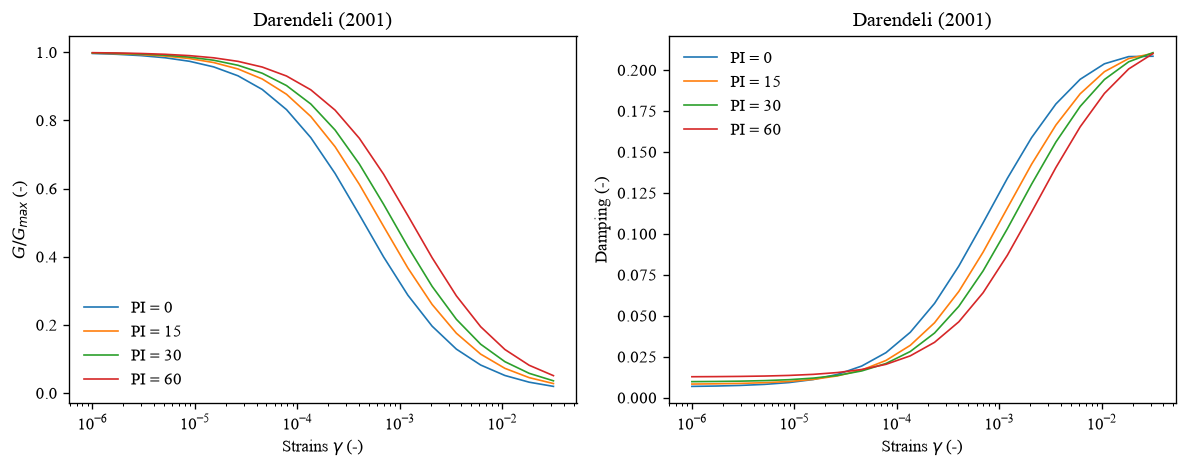

In [9]:
# Plots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Modulus Reduction Curve
for i, row in enumerate(darendelis):
    axs[0].plot(row.mod_reduc.strains, row.mod_reduc.values, lw=1, label = labels_pi[i])
axs[0].set_title('Darendeli (2001)')
axs[0].legend(loc="lower left", frameon=False)
axs[0].set(xlabel=r"Strains $\gamma$ (-)", xscale="log", ylabel=r"$G/G_{max}$ (-)")

# Damping 
for i, row in enumerate(darendelis):
    axs[1].plot(row.damping.strains, row.damping.values, lw=1, label = labels_pi[i])
axs[1].set_title('Darendeli (2001)')
axs[1].legend(loc="upper left", frameon=False)
axs[1].set(xlabel=r"Strains $\gamma$ (-)", xscale="log", ylabel="Damping (-)")


plt.tight_layout()
plt.show()


#### 3.2.1.2. Definition of Soil Types

<div class="alert alert-block alert-info">
    <h5 style="margin-top: 0; margin-bottom: 8px;"><b>Remember</b></h5>
    Parameters that influence dynamic properties of soils:</br>
    <ul style="margin-top: 8px; margin-bottom: 0; padding-left: 20px;">
        <li><b>Clays.</b> Plasticity (PI)</li>
        <li><b>Sands.</b> Void ratio, Coefficient of uniformity, <b>Confining pressure<b></li>
    </ul>
</div>



For our problem, we will use the following `Soil Types`:

| **Layer** | **Depth (m)**  | **Soil Type**  | Model | $\gamma$ (kN/m3) | OCR | PI |  $\zeta$ |
| :--:      | :--:           |  :--:          |  :--:      |  :------:      |  :---: | :---: |:---: |
| 1         |  0.0 - 6.0     | Clay           | Vucetic and Dobry (1991)  | 18 | 1 | 15 | - |
| 2         |  6.0 - 30.5    |  Clay          | Vucetic and Dobry (1991)  | 18 | 1 | 30 | - |
| 3         | 30.5 - 61.0    | Sand           | Darendeli (2001)          | 19 | - | -  | - |
| 4         | 61.0 - 91.0    | Weathered rock | Schnabel (1973)           | 22 | - | -  | - |
| 5         | 91.0 - $\infty$| Bedrock        | -                         | 22 | - | -  | 0.02 |

The definition of the clayey layer materials is straightforward:

In [10]:
clay1 = pystrata.site.SoilType.from_published(unit_wt=18, model="Vucetic & Dobry (91), PI=15")
clay2 = pystrata.site.SoilType.from_published(unit_wt=18, model="Vucetic & Dobry (91), PI=30")

For the sandy layer, we will need to estimate the mean effective stress ($\sigma_{m}'$) using the formula:

$$\sigma_{m}' = \frac{1}{3}\left[\sigma_{1}'+\sigma_{2}'+\sigma_{3}'\right]$$

Considering:

$$\sigma_{1}' = \sigma_{v}'$$
$$\sigma_{2}' = \sigma_{3}' = \sigma_{h}'$$
$$\sigma_{h} = K_0 * \sigma_{v}'$$
$$\sigma_{v}' = \sigma_{v} - u_0$$

Since the sandy layer is 30 m thick, it is recommended to subdivide it into sublayers to adequately capture the variation of $\sigma_{m}'$ with depth. For our example, we will use three sublayers: 

- sand1. Depth: 30.5 - 39 m
- sand2. Depth: 39 - 49 m
- sand3. Depth: 49 - 61 m

Assuming $K_0 = 0.5$ and considering that the GWT is at 6 m depth with hydrostatic conditions, we can estimate the value of $\sigma_{m}'$ at the midpoint of each sublayer:


| **Sublayer**  | **Depth (m)**  | **Thickness (m)**  | **Midpoint depth (m)** | $\sigma_{v}$ (kPa) | $u$ (kPa) | $\sigma_{v}'$ (kPa) |  $\sigma_{m}'$ (kPa) |
| :--:          | :--:           |  :--:              |  :--:                  |  :------:          |  :---:     | :---:   |:---: |
| sand1         | 30.5 - 39.0    | 8.5                | 34.75                  | 629.8  | 282.0 | 347.8 | 231.9 |
| sand2         | 39.0 - 49.0    | 10.0               | 44.00                  | 805.5  | 372.8 | 432.7 | 288.5 |
| sand3         | 49.0 - 61.0    | 12.0               | 55.00                  | 1014.5 | 480.7 | 533.8 | 355.9 |

Thus:

In [14]:
sand1 = pystrata.site.DarendeliSoilType(19.0, plas_index=0,  ocr=1.0, stress_mean=231.9)
sand2 = pystrata.site.DarendeliSoilType(19.0, plas_index=0,  ocr=1.0, stress_mean=288.5)
sand3 = pystrata.site.DarendeliSoilType(19.0, plas_index=0,  ocr=1.0, stress_mean=355.9)

Schnabel's (1973) curves are typically used in practice to model rock nonlinear behavior. These curves are not part of the **pySTRATA** catalog. So, we will define it manually using the class `NonlinearProperty()`: 

In [15]:
# Schnabel (1973) curves
strains_mod_reduc = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 1]
mod_reduc_values = [1, 1, 0.99, 0.95, 0.9, 0.81, 0.725, 0.55]
strains_damping = [0.0001, 0.001, 0.01, 0.1, 1]
damping_values = [0.004, 0.008, 0.015, 0.030, 0.046]

# Create user-defined curve objects
mod_reduc_SCH73 = pystrata.site.NonlinearProperty("Schnabel (1973)", strains_mod_reduc, mod_reduc_values, "mod_reduc")
damping_SCH73 = pystrata.site.NonlinearProperty("Schnabel (1973)", strains_damping, damping_values, "damping")

# Create a SoilType using the custom curves
wea_rock = pystrata.site.SoilType(name="Schnabel (1973)", unit_wt=18.0,
                                  mod_reduc=mod_reduc_SCH73,damping=damping_SCH73)

For the bedrock, we will assume a linear behavior (`mod_reduc` = `None`, `damping` = constant):

In [13]:
bedrock = pystrata.site.SoilType("Bedrock", 22.0, None, 0.02)

### 3.2.2. Layer discretization

**pySTRATA** assigns the same stiffness and damping at each point within a layer. Thus, we need to **discretize our soil profile** to avoid misrepresenting soil stiffness degradation and the corresponding miscalculation of stress and strains with depth. Given that `LIN` analysis asumes constant properties in each layer, the above is only critical for `EQL` and `FDM` analysis.

In general, we want finer layers at the top. Some recommendations for profile discretization (Dr. Rodriguez-Marek personal communication):

- `Near the surface`: Thickness $\leq$ 1 m 
- `Below about 6.1 m`: Thickness $\leq$ 1.5 m 
- `Below 30.5 m`: Thickness $\leq$ 3 m

For our study case:

| **Layer** | **Depth (m)**  |  **Soil Type**  | Thickness (m) | $V_{S}$ (m/s) | 
| :--:      | :--:           | :--:            | :--:          |  :--:         |  
| 1         |  0.0 - 6.0     | clay1           | 6.0           |  250 |
| 2         |  6.0 - 30.5    | clay2           | 24.5          |  300 |
| 3         | 30.5 - 61.0    | sand1           | 30.5          |  460 |
| 4         | 61.0 - 91.0    | wea_rock        | 30.0          |  700 |
| 5         | 91.0 - $\infty$| bedrock         | -             |  1850 |

To create the profile, we use the class `pystrata.site.Profile()`, and each layer is defined using the class `pystrata.site.Layer()` (Note: thickness = 0 to indicate an elastic half-space):

In [16]:
profile = pystrata.site.Profile(
    [
        # Clay 1. Thickness = 6 m
        pystrata.site.Layer(clay1, 0.5, 250),
        pystrata.site.Layer(clay1, 0.5, 250),
        pystrata.site.Layer(clay1, 1, 250),
        pystrata.site.Layer(clay1, 1, 250),
        pystrata.site.Layer(clay1, 1, 250),
        pystrata.site.Layer(clay1, 1, 250),
        pystrata.site.Layer(clay1, 1, 250),
        # Clay 2. Thickness = 24.5 m
        pystrata.site.Layer(clay2, 1, 300),
        pystrata.site.Layer(clay2, 1, 300),
        pystrata.site.Layer(clay2, 1, 300),
        pystrata.site.Layer(clay2, 1, 300),
        pystrata.site.Layer(clay2, 1, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        pystrata.site.Layer(clay2, 1.5, 300),
        # Sand 1. Thickness = 8.5 m 
        pystrata.site.Layer(sand1, 1.5, 460),
        pystrata.site.Layer(sand1, 1.5, 460),
        pystrata.site.Layer(sand1, 1.5, 460),
        pystrata.site.Layer(sand1, 2, 460),
        pystrata.site.Layer(sand1, 2, 460),
        # Sand 2. Thickness = 10.0 m
        pystrata.site.Layer(sand2, 2, 460),
        pystrata.site.Layer(sand2, 2, 460),
        pystrata.site.Layer(sand2, 2, 460),
        pystrata.site.Layer(sand2, 2, 460),
        pystrata.site.Layer(sand2, 2, 460),
        # Sand 3. Thickness = 12.0 m
        pystrata.site.Layer(sand3, 2, 460),
        pystrata.site.Layer(sand3, 2, 460),
        pystrata.site.Layer(sand3, 2, 460),
        pystrata.site.Layer(sand3, 2, 460),
        pystrata.site.Layer(sand3, 2, 460),
        pystrata.site.Layer(sand3, 2, 460),
        # Weathered Rock, Thickness = 30
        pystrata.site.Layer(wea_rock, 2.5, 700),
        pystrata.site.Layer(wea_rock, 2.5, 700), 
        pystrata.site.Layer(wea_rock, 2.5, 700), 
        pystrata.site.Layer(wea_rock, 2.5, 700), 
        pystrata.site.Layer(wea_rock, 2.5, 700), 
        pystrata.site.Layer(wea_rock, 2.5, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        pystrata.site.Layer(wea_rock, 3, 700), 
        # Bedrock
        pystrata.site.Layer(bedrock, 0, 1850) # Assign thickness 0 to indicate Halfspace
    ]
)

Checking the soil profile:

<Axes: xlabel='Initial $V_s$ (m/s)', ylabel='Depth (m)'>

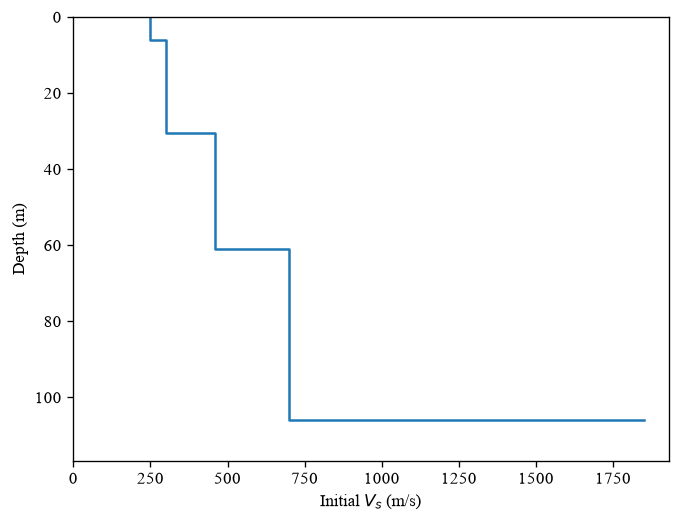

In [17]:
profile.plot("initial_shear_vel")

**pySTRATA** has an automatic discretization tool that it is handy when using randomized shear-wave profiles. The maximum thickness ($h_{max,i}$) of the sublayers of *i*-th velocity layer is taken as a fraction of the minimum wavelength to be captured by the analysis ($\lambda_{min}$):

$$h_{max,i} = \lambda_{frac}\lambda_{min} = \lambda_{frac}\frac{V_{S,i}}{f_{max}}$$

where $\lambda_{frac}$ is the wavelength fraction (typically between 1/10 and 1/5), $f_{max}$ is the maximum frequency of engineering interest (typically around 20 Hz), and $V_{S,i}$ is the shear-wave velocity of the i-th layer. The actual thickness of the sublayers is less than $h_{max,i}$, so the velocity layer height divided by the sub-layer thickness is a whole number.

In [18]:
# Raw profile definition
raw_profile = pystrata.site.Profile([
    pystrata.site.Layer(clay1, 6, 250), 
    pystrata.site.Layer(clay2, 24.5, 300), 
    pystrata.site.Layer(sand1, 30.5, 460),
    pystrata.site.Layer(wea_rock, 30.5, 700),
    pystrata.site.Layer(bedrock, 0, 1850)
])

# Layer autodiscretization to resolve frequencies up to 50 Hz
auto_discretized_profile = raw_profile.auto_discretize(max_freq=50.0, wave_frac=0.2)

## 3.3. Selection of Analysis Method


```mermaid
flowchart LR
    A[Define <br>input motion] --> B[Creation <br>site profile]
    B --> C[Selection <br>analysis method]
    C --> D[Output <br>definition]
    D --> E[Run <br>analysis]
    E --> F[Extract/Visualize <br>results]

    %% Color Style for Node A
    style C fill:#bbf,stroke:#333,stroke-width:2px,color:#000
```

To indicate the analysis method, we have to create a site response calculator using the following classes:

- ``LE``: Fastest method; assumes constant soil properties `pystrata.propagation.LinearElasticCalculator()`
- ``EQL``: Iterative method accounting for strain-dependent soil properties `pystrata.propagation.EquivalentLinearCalculator(()`
- ``FDM``: Advanced nonlinear approach using frequency domain convolution `pystrata.propagation.FrequencyDependentEqlCalculator()`. It supports two methods 1) [Kausel & Assimaki (2002)](https://ascelibrary.org/doi/10.1061/%28ASCE%290733-9399%282002%29128%3A1%2834%29) (ka02); and 2) [Zalachoris & Rathje (2015)](https://ascelibrary.org/doi/abs/10.1061/%28ASCE%29GT.1943-5606.0001366) (zr15).

For the case study, we will compare the difference obtained using the Linear Elastic (`LE`) and Equivalent Linear (`EQL`) approaches. For the `EQL`, we have to define:

- `strain_ratio`: Ratio between the maximum strain and effective strain used to compute the strain-compatible properties, default 0.65
- `tolerance`: tolerance of the iterative properties, default 0.01
- `max_iterations`: maximum number of iterations to perform, default 15
- `strain_limit`: maximum strain accepeted in the calculations; if exceeded, the calculation is ended, default 0.05



In [19]:
calcs = [
    ("LE", pystrata.propagation.LinearElasticCalculator()),
    ("EQL", pystrata.propagation.EquivalentLinearCalculator(strain_ratio=0.65, max_iterations=30, strain_limit=0.02))
]

## 3.4. Definition of Outputs


```mermaid
flowchart LR
    A[Define <br>input motion] --> B[Creation <br>site profile]
    B --> C[Selection <br>analysis method]
    C --> D[Output <br>definition]
    D --> E[Run <br>analysis]
    E --> F[Extract/Visualize <br>results]

    %% Color Style for Node A
    style D fill:#bbf,stroke:#333,stroke-width:2px,color:#000
```

**PyStrata** provides many output types for different analysis needs. These can be grouped by:

- **Location**: Track variable values at a specific point in the profile.
    - **Time Series**:
        - **Acceleration** (g): `AccelerationTSOutput(location)`
        - **Arias Intensity** (m/s): `AriasIntensityTSOutput(location)`
        - **Strain** (-): `StrainTSOutput(location, in_percent=False)`
        - **Stress** (kPa): `stressTSOutput(location, damped=False, normalized=False)`
    - **Fourier Amplitude Spectrum**: `FourierAmplitudeSpectrumOutput(freqs, location, ko_bandwidth=30)`
    - **PSA - Response Spectrum**: `ResponseSpectrumOutput(freqs, location, osc_damping)`
- **Ratio**: Transfer functions; it requires the definition of the denominator and numerator
    - **Acceleration Transfer Functions**: `AccelTransferFunctionOutput(location_in, location_out, ko_bandwidth=None, absolute=True)`
    - **PSA - Response Spectrum Ratio**: `ResponseSpectrumRatioOutput(freqs, location_in, location_out, ko_bandwidth=None, absolute=True)`
- **Profile**: Track variable values with depth.
    - **Maximum Strain** ($\gamma_{max}$): `MaxStrainProfile()`
    - **Damping** ($\zeta$): `DampingProfile()`
    - **Shear Modulus Reduction** ($G/G_{max}$): `ShearModReducProfile()`
    - **Initial Velocity** (m/s): `InitialVelProfile()`
    - **Strain-compatible Velocity** (m/s): `CompatVelProfile()`
    - **Cyclic Stress Ratio**: `CyclicStressRatioProfile()`
    - **Maximum Acceleration** (g): `MaxAccelProfile()`

The arguments in these classes are:

- **location**: It is defined as a `pystrata.output.OutputLocation(wave_field, depth, index)` class. It specifies the position in the soil profile **where** the calculation is evaluated and its **boundary type**, where:
    - `wave_field`: boundary type. It can be:
        - `outcrop`: Represents a free surface or exposed rock outcrop. It includes both the upward wave and the reflected downward wave (2E).
        - `within`: Represents motion inside a soil layer below the surface. It incorporates both upward (E) and downward (F) wave fields (E+F).
        - `incoming`: Represents only the upward-propagating incident wave (E).
    - `depth`: depth of interest. If provided, index is ignored.
    - `index`: Index of the layer of interest. If provided, then depth is ignored. Results are provided at top of the layer.
- **freqs**: Array of frequencies to evaluate the spectrum, default np.logspace(-1, 2, num=301).
- **ko_bandwidth**: parameter of [Konno-Ohmachi](https://pubs.geoscienceworld.org/ssa/bssa/article-abstract/88/1/228/102764/Ground-motion-characteristics-estimated-from?redirectedFrom=fulltext) filter for spectral smoothing, default 30.
- **osc_damping**: Damping of the oscillator for the PSA, default 0.05.

For our case study, we will analyze:

- **Acceleration Time Series** at surface
- **Pseudo-Acceleration Respond Spectrum** at surface
- **Acceleration Transfer Function** surface/bedrock
- **Strain-compatible Velocity**

In [20]:
freqs = np.logspace(-1, 2, num=500)

outputs = pystrata.output.OutputCollection(
    [
        pystrata.output.AccelerationTSOutput(
            pystrata.output.OutputLocation("outcrop", index=0) # location
        ),
        pystrata.output.ResponseSpectrumOutput(
            # Frequency
            freqs,
            # Location of the output
            pystrata.output.OutputLocation("outcrop", index=0),
            # Damping
            0.05,
        ),
        pystrata.output.AccelTransferFunctionOutput(
            # Frequency
            freqs,
            # Location in (denominator),
            pystrata.output.OutputLocation("outcrop", index=-1),
            # Location out (numerator)
            pystrata.output.OutputLocation("outcrop", index=0),
        ),
        pystrata.output.CompatVelProfile()
    ]
)

## 3.5. Run analysis


```mermaid
flowchart LR
    A[Define <br>input motion] --> B[Creation <br>site profile]
    B --> C[Selection <br>analysis method]
    C --> D[Output <br>definition]
    D --> E[Run <br>analysis]
    E --> F[Extract/Visualize <br>results]

    %% Color Style for Node A
    style E fill:#bbf,stroke:#333,stroke-width:2px,color:#000
```

To run the analyses, we have to define the input ground motion, its location, and the profile in the `calcs` object. To define the location of the input ground motion, we use the class `profile.location(wave_field, depth, index)`. Finally, we have to calculate all of the outputs from the calculation object:

In [21]:
for name, calc in calcs:
    calc(NIS090, profile, profile.location("outcrop", index=-1))
    outputs(calc, name)

<Location(layer_index=0, depth_within=0 wave_field=WaveField.outcrop)>
<Location(layer_index=0, depth_within=0 wave_field=WaveField.outcrop)>


## 3.6. Extract/Visualize the results


```mermaid
flowchart LR
    A[Define <br>input motion] --> B[Creation <br>site profile]
    B --> C[Selection <br>analysis method]
    C --> D[Output <br>definition]
    D --> E[Run <br>analysis]
    E --> F[Extract/Visualize <br>results]

    %% Color Style for Node A
    style F fill:#bbf,stroke:#333,stroke-width:2px,color:#000
```

The results of our analysis are saved in the object `outputs`:

In [22]:
for o in outputs:
    print(o)

### 3.6.1. Acceleration Time Series

We can access to the acceleration time series data (or any **time series** data) with `times` and `values` attributes (arrays with two columns, one for each calculator):

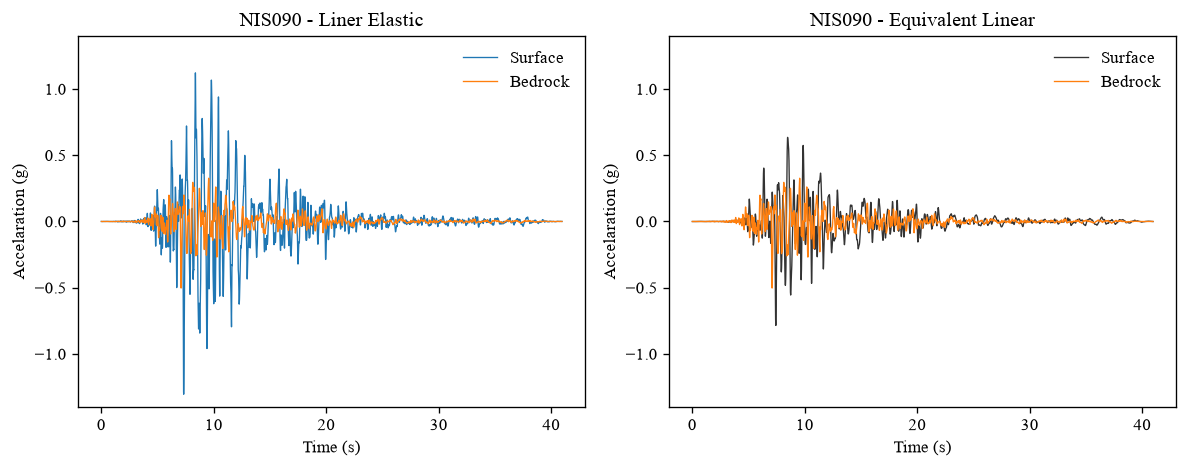

In [23]:
# Retreaving information
NIS090_surface_LE_times = outputs[0].times[:,0]
NIS090_surface_LE_accels = outputs[0].values[:,0]

NIS090_surface_EQL_times = outputs[0].times[:,1]
NIS090_surface_EQL_accels = outputs[0].values[:,1]

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# LE
ax1.plot(NIS090_surface_LE_times, NIS090_surface_LE_accels, color = '#1f77b4', lw=0.8, label="Surface")
ax1.plot(NIS090.times, NIS090.accels, color='#ff7f0e', lw=0.8, label = "Bedrock")
ax1.set_title('NIS090 - Liner Elastic')
ax1.set_ylim([-1.4, 1.4])
ax1.legend(loc="upper right", frameon=False)
ax1.set(xlabel="Time (s)", ylabel="Accelaration (g)")

# EQL
ax2.plot(NIS090_surface_EQL_times, NIS090_surface_EQL_accels, color = '#333333', lw=0.8, label="Surface")
ax2.plot(NIS090.times, NIS090.accels, color='#ff7f0e', lw=0.8, label = "Bedrock")
ax2.set_title('NIS090 - Equivalent Linear')
ax2.set_ylim([-1.4, 1.4])
ax2.legend(loc="upper right", frameon=False)
ax2.set(xlabel="Time (s)", ylabel="Accelaration (g)")

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>Question:</b> What are the main differences between the results obtained with the Linear Elastic and Equivalent Linear methods?
</div>

### 3.6.2. PSA Response Spectrum

We can access to the PSA Response Spectrum data (or any **location** data) with the `output.to_dataframe()` method:

In [24]:
PSA_NIS090_surface = outputs[1].to_dataframe()
PSA_NIS090_surface.head()

,LE,EQL
0.100000,0.009763,0.010038
0.101394,0.009160,0.009511
0.102807,0.008735,0.009057
0.104240,0.008552,0.008788
0.105693,0.008998,0.008711


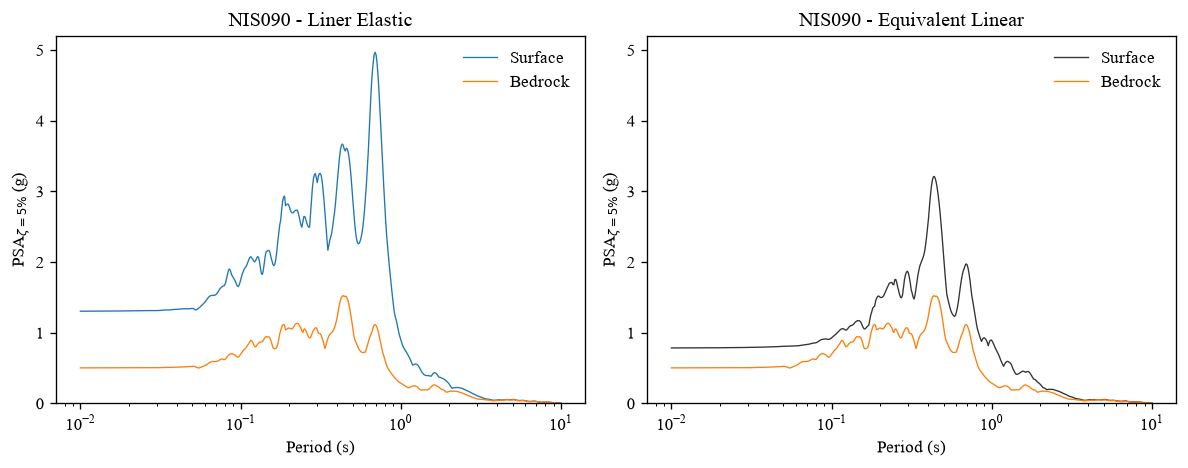

In [29]:
# Retreaving information
periods_PSA_sur = 1/PSA_NIS090_surface['LE'].index.to_numpy()
PSA_NIS090_sur_LE = PSA_NIS090_surface['LE'].to_numpy()
PSA_NIS090_sur_EQL = PSA_NIS090_surface['EQL'].to_numpy()

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# LE
ax1.plot(periods_PSA_sur, PSA_NIS090_sur_LE, color = '#1f77b4', lw=0.8, label="Surface")
ax1.plot(periods_PSA, PSA_NIS090,  color='#ff7f0e', lw=0.8, label = "Bedrock")
ax1.set_title('NIS090 - Liner Elastic')
ax1.set_ylim([0,5.2])
ax1.legend(loc="upper right", frameon=False)
ax1.set(xlabel="Period (s)", xscale = 'log', ylabel=r"PSA$_{\zeta=5\%}$ (g)")

# EQL
ax2.plot(periods_PSA_sur, PSA_NIS090_sur_EQL, color = '#333333', lw=0.8, label="Surface")
ax2.plot(periods_PSA, PSA_NIS090, color='#ff7f0e', lw=0.8, label = "Bedrock")
ax2.set_title('NIS090 - Equivalent Linear')
ax2.set_ylim([0,5.2])
ax2.legend(loc="upper right", frameon=False)
ax2.set(xlabel="Period (s)", xscale = 'log', ylabel=r"PSA$_{\zeta=5\%}$ (g)")

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>Question:</b> Are the differences between the Linear Elastic and the Equivalent Linear methods the same for all periods?
</div>

### 3.6.3. Acceleration Transfer Function

Similarly to the PSA Response Spectrum, we can access the Acceleration Transfer Function data (or any **ratio based** data) with the `output.to_dataframe()` method:

In [30]:
TF_NIS090_surface = outputs[2].to_dataframe()
TF_NIS090_surface.head()

,LE,EQL
0.100000,1.006699,1.013667
0.101394,1.006915,1.014099
0.102807,1.007134,1.014538
0.104240,1.007355,1.014982
0.105693,1.007580,1.015432


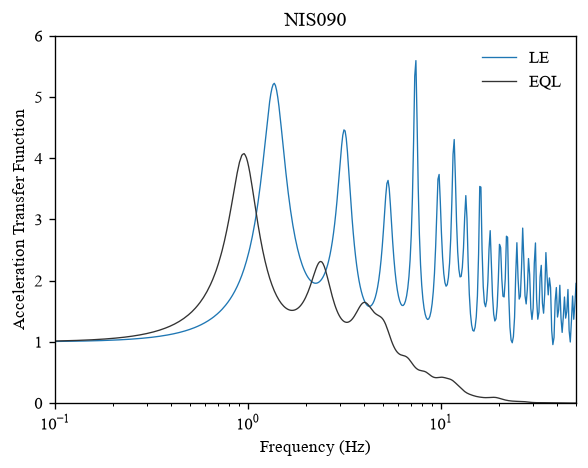

In [31]:
# Retreaving information
freqs_TF = TF_NIS090_surface['LE'].index.to_numpy()
TF_NIS090_LE = TF_NIS090_surface['LE'].to_numpy()
TF_NIS090_EQL = TF_NIS090_surface['EQL'].to_numpy()

# Plot
fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(freqs_TF, TF_NIS090_LE, color = '#1f77b4', lw=0.8, label="LE")
ax.plot(freqs_TF, TF_NIS090_EQL,  color = '#333333', lw=0.8, label="EQL")
ax.set_title('NIS090')
ax.set_ylim([0,6])
ax.set_xlim([0.1,50])
ax.legend(loc="upper right", frameon=False)
ax.set(xlabel="Frequency (Hz)", xscale = 'log', ylabel="Acceleration Transfer Function")

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>Question 1:</b> Is the fundamental frequency the same in both methods? </br>
<b>Question 2:</b> What happens at high frequencies in the EQL method? Is it reasonable?
</div>

### 3.6.4. Strain-Compatible Shear Wave Velocity

Similarly to the acceleration time series, we can access  the Strain-Compatible Shear Wave Velocity data (or any **profile** data) with the `refs` and `values` attributes (arrays with two columns, one for each calculator):

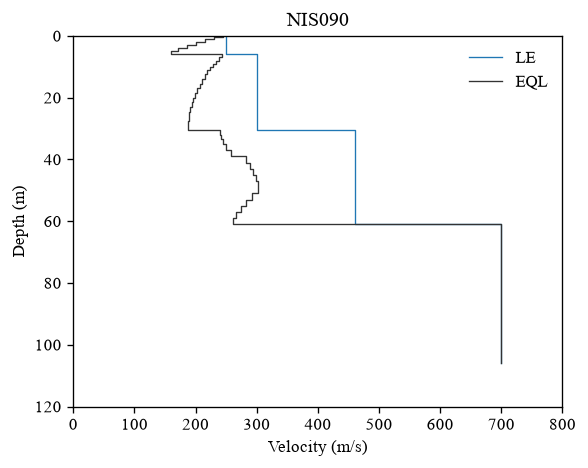

In [32]:
# Retreaving information
z1 = outputs[3].refs[:,0]
vel_NIS090_LE = outputs[3].values[:,0]
z2 = outputs[3].refs[:,1]
vel_NIS090_EQL = outputs[3].values[:,1]

# Plot
fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(vel_NIS090_LE, z1 , color = '#1f77b4', lw=0.8, label="LE", drawstyle='steps-post')
ax.plot(vel_NIS090_EQL, z2,  color = '#333333', lw=0.8, label="EQL", drawstyle='steps-post')
ax.set_title('NIS090')
ax.set_ylim([0,120])
ax.set_xlim([0,800])
ax.legend(loc="upper right", frameon=False)
ax.invert_yaxis()
ax.set(xlabel="Velocity (m/s)", ylabel="Depth (m)")

plt.tight_layout()
plt.show()